In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from collections import Counter

print("Libraries imported successfully!")

Libraries imported successfully!


In [32]:
df = pd.read_csv("dataset/twitter_training.csv", header=None)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (74682, 4)


,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [33]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (74682, 4)

Column Names:
[0, 1, 2, 3]

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       74682 non-null  int64 
 1   1       74682 non-null  object
 2   2       74682 non-null  object
 3   3       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB

First 5 Rows:


,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Missing Values:
0      0
1      0
2      0
3    686
dtype: int64


In [34]:
df.columns = ["Tweet_ID", "Entity", "Sentiment", "Text"]

print("Columns renamed successfully!")

print("\nSentiment Classes:")
print(df["Sentiment"].value_counts())

print("\nNumber of unique sentiment classes:")
print(df["Sentiment"].nunique())

Columns renamed successfully!

Sentiment Classes:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Number of unique sentiment classes:
4


Sentiment Distribution:


Sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64

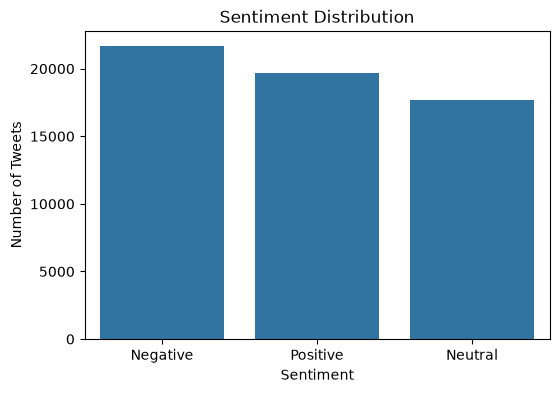

In [35]:
# Sentiment Distribution for the 3 required classes

sentiment_counts = df_sentiment["Sentiment"].value_counts()

print("Sentiment Distribution:")
display(sentiment_counts)

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_sentiment,
    x="Sentiment",
    order=["Negative", "Positive", "Neutral"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [36]:
# NLTK setup and Text Preprocessing

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

# Create stopwords set
stop_words = set(stopwords.words("english"))

# Text preprocessing function
def preprocess_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and non-alphabetic words
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(tokens)


# Apply preprocessing
df_sentiment["Clean_Text"] = df_sentiment["Text"].apply(preprocess_text)

print("Text preprocessing completed!")

display(
    df_sentiment[["Text", "Clean_Text", "Sentiment"]].head()
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lucky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Text preprocessing completed!


,Text,Clean_Text,Sentiment
0,im getting on borderlands and i will murder yo...,im getting borderlands murder,Positive
1,I am coming to the borders and I will kill you...,coming borders kill,Positive
2,im getting on borderlands and i will kill you ...,im getting borderlands kill,Positive
3,im coming on borderlands and i will murder you...,im coming borderlands murder,Positive
4,im getting on borderlands 2 and i will murder ...,im getting borderlands murder,Positive


### TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert text data into numerical features that can be processed by machine learning algorithms.

TF-IDF gives higher importance to words that are frequent in a particular document but less frequent across the entire collection of documents. Common words that appear in many documents receive lower importance.

In this project, TF-IDF is applied to the cleaned tweet text to transform textual data into numerical feature vectors for sentiment classification.

In [37]:
# Data Cleaning Before Feature Extraction

print("Before Cleaning:")
print("Shape:", df_sentiment.shape)
print("Missing Text:", df_sentiment["Text"].isna().sum())
print("Duplicate Rows:", df_sentiment.duplicated().sum())

# Remove rows with missing text
df_sentiment = df_sentiment.dropna(subset=["Text"]).copy()

# Remove duplicate rows
df_sentiment = df_sentiment.drop_duplicates().copy()

print("\nAfter Cleaning:")
print("Shape:", df_sentiment.shape)
print("Missing Text:", df_sentiment["Text"].isna().sum())
print("Duplicate Rows:", df_sentiment.duplicated().sum())

Before Cleaning:
Shape: (59119, 5)
Missing Text: 0
Duplicate Rows: 0

After Cleaning:
Shape: (59119, 5)
Missing Text: 0
Duplicate Rows: 0


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert cleaned text into numerical features
X = tfidf.fit_transform(df_sentiment["Clean_Text"])

print("TF-IDF feature extraction completed!")
print("Feature Matrix Shape:", X.shape)
print("Number of Features:", len(tfidf.get_feature_names_out()))

TF-IDF feature extraction completed!
Feature Matrix Shape: (59119, 5000)
Number of Features: 5000


In [39]:
from sklearn.model_selection import train_test_split

# Target variable
y = df_sentiment["Sentiment"]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Training set shape: (47295, 5000)
Testing set shape: (11824, 5000)

Training sentiment distribution:
Sentiment
Negative    17358
Positive    15770
Neutral     14167
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment
Negative    4340
Positive    3943
Neutral     3541
Name: count, dtype: int64


In [40]:
from sklearn.naive_bayes import MultinomialNB

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes model trained successfully!")
print("Number of predictions:", len(y_pred_nb))

Naive Bayes model trained successfully!
Number of predictions: 11824


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

print("Naive Bayes Evaluation")
print("----------------------")
print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1-Score  : {nb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))

Naive Bayes Evaluation
----------------------
Accuracy  : 0.7088
Precision : 0.7124
Recall    : 0.7088
F1-Score  : 0.7041

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.82      0.75      4340
     Neutral       0.74      0.54      0.63      3541
    Positive       0.71      0.74      0.72      3943

    accuracy                           0.71     11824
   macro avg       0.71      0.70      0.70     11824
weighted avg       0.71      0.71      0.70     11824



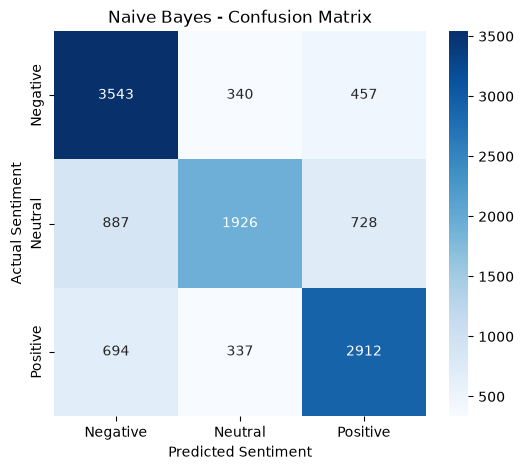

In [42]:
# Naive Bayes Confusion Matrix

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [43]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")
print("Number of predictions:", len(y_pred_lr))

Logistic Regression model trained successfully!
Number of predictions: 11824


In [44]:
# Logistic Regression Evaluation

lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Evaluation")
print("------------------------------")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-Score  : {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))

Logistic Regression Evaluation
------------------------------
Accuracy  : 0.7506
Precision : 0.7504
Recall    : 0.7506
F1-Score  : 0.7504

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79      4340
     Neutral       0.69      0.69      0.69      3541
    Positive       0.77      0.75      0.76      3943

    accuracy                           0.75     11824
   macro avg       0.75      0.75      0.75     11824
weighted avg       0.75      0.75      0.75     11824



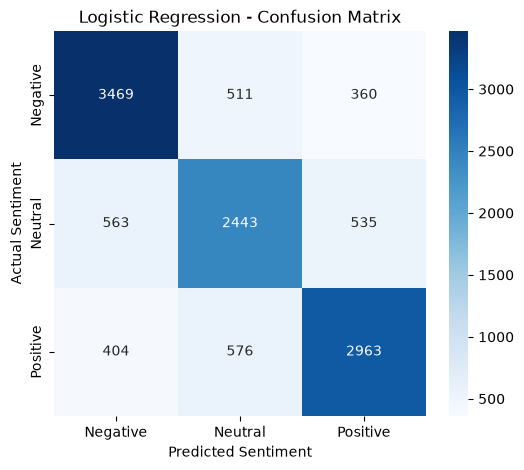

In [45]:
# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [46]:
# Model Performance Comparison

comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1-Score": [nb_f1, lr_f1]
})

comparison = comparison.round(4)

display(comparison)

# Identify the best model based on F1-Score
best_model = comparison.loc[
    comparison["F1-Score"].idxmax(), "Model"
]

print(f"\nBest Performing Model based on F1-Score: {best_model}")

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7088,0.7124,0.7088,0.7041
1,Logistic Regression,0.7506,0.7504,0.7506,0.7504



Best Performing Model based on F1-Score: Logistic Regression


In [47]:
# Error Analysis - 5 Misclassified Examples

if best_model == "Naive Bayes":
    predictions = y_pred_nb
else:
    predictions = y_pred_lr

error_analysis = df_sentiment.loc[
    y_test.index,
    ["Text", "Sentiment"]
].copy()

error_analysis["Predicted Sentiment"] = predictions

# Keep only misclassified examples
misclassified = error_analysis[
    error_analysis["Sentiment"] != error_analysis["Predicted Sentiment"]
]

print("Total Misclassified Examples:", len(misclassified))

print("\nFive Misclassified Examples:")
display(misclassified.head(5))

Total Misclassified Examples: 2949

Five Misclassified Examples:


,Text,Sentiment,Predicted Sentiment
71813,Ghost Recon Free download update 1.09 with AI ...,Positive,Neutral
72646,and Nvidia 3090 day be like .. oh BROKEN again...,Positive,Negative
46618,Apple Touch iPhone 7 Plus includes a1661 32GB ...,Neutral,Positive
72223,So I just faced the first Terminator and let m...,Positive,Negative
26497,I don't understand the hatred of Assassin's Creed,Positive,Negative


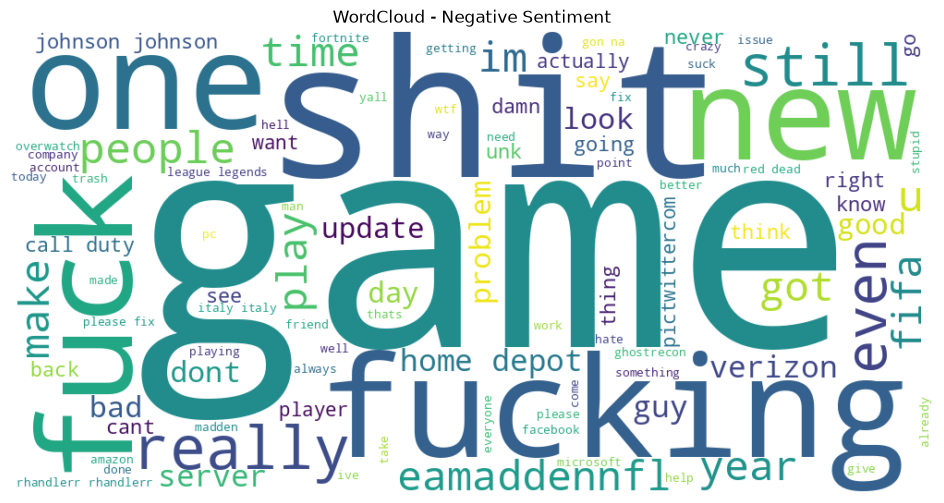

In [48]:
from wordcloud import WordCloud

# Negative sentiment text
negative_text = " ".join(
    df_sentiment.loc[
        df_sentiment["Sentiment"] == "Negative",
        "Clean_Text"
    ]
)

# Generate Negative WordCloud
wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Negative Sentiment")
plt.show()

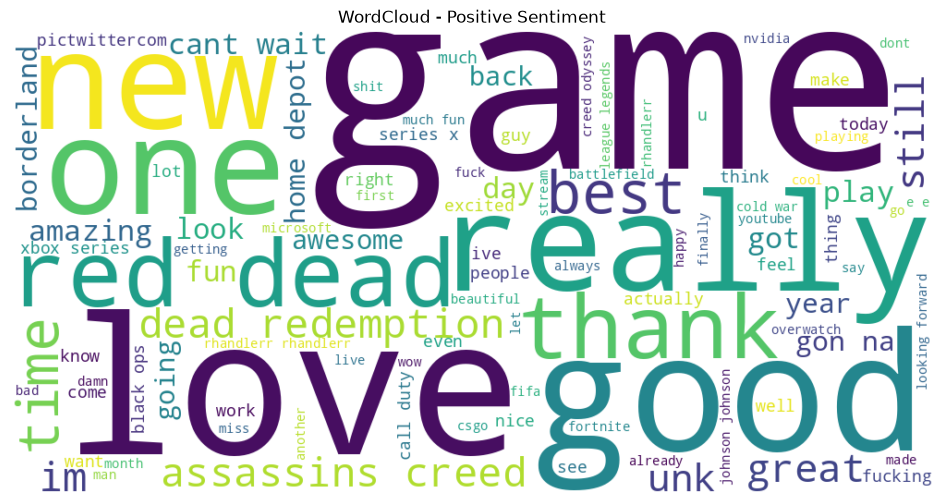

In [49]:
# Positive sentiment text
positive_text = " ".join(
    df_sentiment.loc[
        df_sentiment["Sentiment"] == "Positive",
        "Clean_Text"
    ]
)

# Generate Positive WordCloud
wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Positive Sentiment")
plt.show()

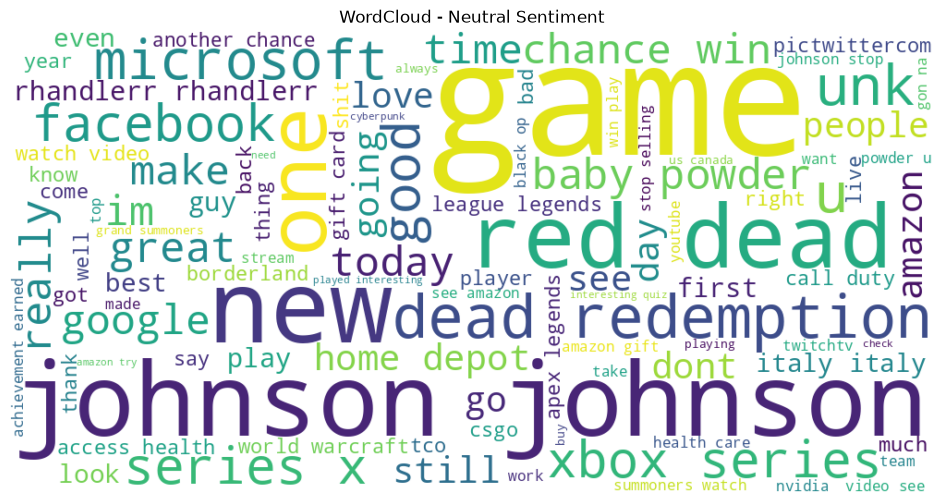

In [50]:
# Neutral sentiment text
neutral_text = " ".join(
    df_sentiment.loc[
        df_sentiment["Sentiment"] == "Neutral",
        "Clean_Text"
    ]
)

# Generate Neutral WordCloud
wordcloud_neutral = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Neutral Sentiment")
plt.show()

## Error Analysis

The following five examples were misclassified by the best-performing sentiment classification model. These errors were examined to understand possible reasons for incorrect predictions.

Common reasons for misclassification may include ambiguous language, sarcasm, mixed sentiment, short text, informal expressions, and context-dependent meaning.

## Conclusion

In this project, a sentiment analysis system was developed to classify tweets into three sentiment categories: Positive, Negative, and Neutral.

The dataset was cleaned by handling missing text values and removing duplicate records. Text preprocessing was performed using lowercase conversion, URL and punctuation removal, tokenization, and stopword removal.

TF-IDF Vectorization was used to convert the cleaned text into numerical features. The dataset was divided into 80% training data and 20% testing data using a stratified split.

Two machine learning classifiers, Naive Bayes and Logistic Regression, were trained and evaluated using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

The model with the higher F1-Score was considered the best-performing model for this sentiment classification task.

Sentiment analysis can be useful in real-world applications such as monitoring customer feedback, analyzing social media opinions, measuring public response, and understanding customer satisfaction.